# PyDoseRT dose calculation from a DICOM dataset

**Author:** Attila Simkó

This example shows how we can load a DICOM-based treatment case and recompute dose with PyDoseRT in four steps:

1. Download and extract a reference DICOM dataset,
2. Load the CT, structures, beam sequence, and reference dose,
3. Initialize the PyDoseRT dose engine and recompute dose,
4. Compare the predicted dose with the reference dose distribution.

This provides a compact example of how PyDoseRT can be used with standard radiotherapy data.

In [1]:
try:
    import pydosert
    print("pydosert is already installed")
except ImportError:
    !pip install pydosert

import numpy as np
import matplotlib.pyplot as plt
import torch
from pathlib import Path
import urllib.request
import zipfile

import pydosert as PDRT
from pydosert.utils.plotting import overlay_mask_outline
from pydosert.data.loaders import load_dicom

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float32

pydosert is already installed


## Load a reference dataset

We use a small DICOM example that includes:

- a CT image of a phantom,
- structure contours,
- a treatment plan,
- and a reference dose distribution.

This lets us compare a PyDoseRT dose calculation against a simple, yet clinically exported reference.

In [2]:
zip_url = "https://raw.githubusercontent.com/UMU-DDI/PyDoseRT/main/examples/data/mr_alderson.zip"

zip_path = Path("data/mr_alderson.zip")
extract_dir = Path("data/mr_alderson")

folder_ready = extract_dir.exists() and any(extract_dir.iterdir())

if not folder_ready:
    zip_path.parent.mkdir(parents=True, exist_ok=True)

    if not zip_path.exists():
        print("Downloading zip...")
        urllib.request.urlretrieve(zip_url, zip_path)

    print("Extracting zip...")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)

    print(f"Done. Extracted to {extract_dir}")
else:
    print(f"{extract_dir} already exists and is not empty, skipping.")

Extracting zip...
Done. Extracted to data/mr_alderson


## Load the patient, beam sequence, and reference dose

Next, we read the DICOM folders and files into PyDoseRT objects.

This step gives us:

- a `Patient` object with CT, structures, and reference dose,
- a beam sequence from the RT plan,
- and a consistent geometry for dose recalculation.

PyDoseRT is **not a DICOM loader**. We aimed to develop a general loader that we tested on our datasets, however it is very likely to break when tested extensively. We recommend building a `BeamSequence` from the plans manually, with the leaf positions, jaw positions and monitor unit values extracted directly from the plans.

In [3]:
# Set paths
ct_folder = "data/mr_alderson/CT/"
rtplan_path = "data/mr_alderson/RP/RP1.2.752.243.1.1.20251104150801227.3200.53550.dcm"
rtdose_path = ["data/mr_alderson/RD/RD1.2.752.243.1.1.20251104150801227.3300.46671.dcm", "data/mr_alderson/RD/RD1.2.752.243.1.1.20251104150801228.3500.71811.dcm"]
rtstruct_path = "data/mr_alderson/RS/RS1.2.752.243.1.1.20251104145623863.1100.46584.dcm"

roi_colors = {
    "PTV": "orange",
    "Bladder": "red",
    "Rectum": "green",
    "FemoralHead_L": "blue",
    "FemoralHead_R": "purple",
    "Body": "black",
}

patient, beam_sequence = load_dicom(
    ct_folder, 
    dose_path=rtdose_path, 
    plan_path=[rtplan_path], 
    struct_path=rtstruct_path, 
    struct_names=["PTV", "Bladder", "Rectum", "FemoralHead_L", "FemoralHead_R", "Body"])
beam_sequence = beam_sequence[0]

## Inspect the loaded beam sequence

Before recomputing dose, it is useful to inspect the imported delivery data.

Here we visualize:

- left MLC positions,
- right MLC positions,
- monitor units across beams.

This provides a quick check that the treatment plan was loaded correctly.

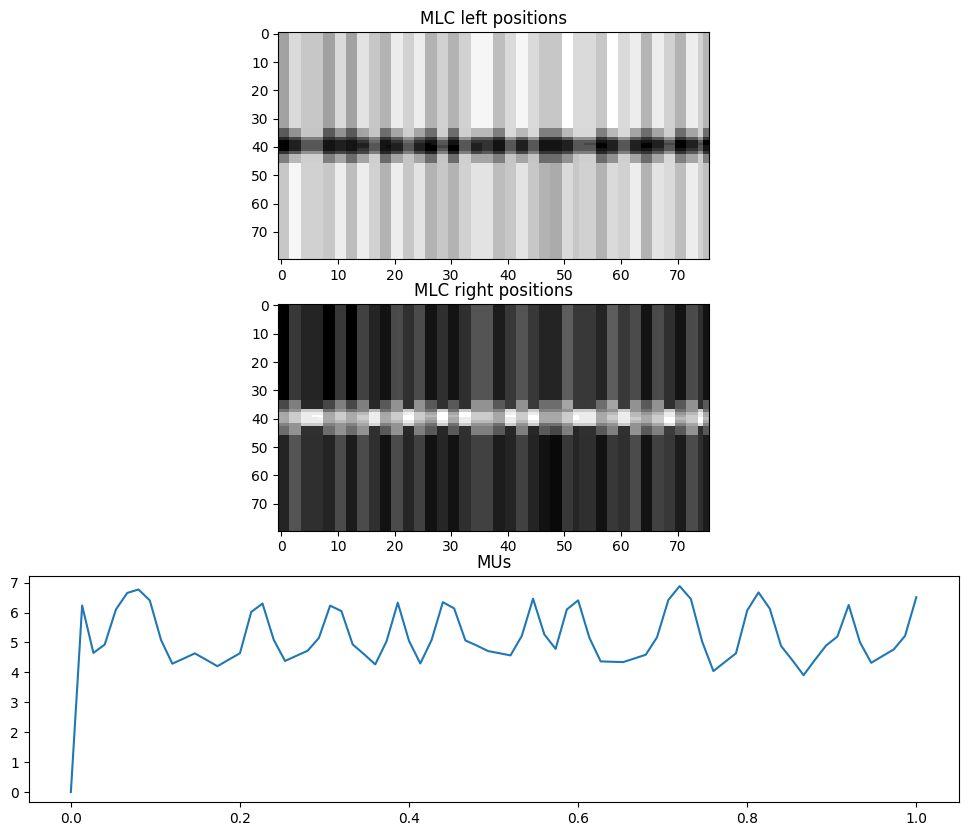

In [4]:
ct_slices = np.array(np.expand_dims(patient._ct_tensor.cpu().detach().numpy(), 0), dtype=np.float32)
leafs_1 = beam_sequence.leaf_positions
mus_1 = beam_sequence.mus

plt.figure(figsize=(12, 10))
plt.axis("off")

plt.subplot(311)
plt.title("MLC left positions")
plt.imshow(
    np.transpose(leafs_1[:, :, 0].cpu().detach().numpy()),
    cmap="gray",
    aspect=0.5,
    interpolation="none",
)

plt.subplot(312)
plt.title("MLC right positions")
plt.imshow(
    np.transpose(leafs_1[:, :, 1].cpu().detach().numpy()),
    cmap="gray",
    aspect=0.5,
    interpolation="none",
)

plt.subplot(313)
plt.title("MUs")
plt.plot(
    np.linspace(0, 1, beam_sequence.num_beams),
    mus_1.cpu().detach().numpy(),
)

plt.show()

## Initialize the dose engine and recompute dose

We now create a PyDoseRT dose engine using the imported beam sequence and patient geometry.

Internally, PyDoseRT uses a differentiable pencil-beam based dose model, so this same setup can also be used later for optimization workflows.

In this example we use the sequential dose computation, which computes dose beam-by-beam, instead of a single call that computes all the beams at once. This saves a significant amount of memory, however it takes slightly more time.

In [5]:
preset_path = Path(pydosert.data.__file__).parent / "machine_presets" / "varian_truebeam_umea_10MV.json"
config = PDRT.MachineConfig(
    preset=str(preset_path),
    number_of_leaf_pairs=80,
    leaf_widths=None,
)

dose_engine = PDRT.DoseEngine(
    config,
    25,
    patient.resolution,
    patient.density_image.shape,
    beam_sequence,
    dtype=torch.float32,
    device=device,
)

dose_pred = dose_engine.compute_dose_sequential(
    beam_sequence.to(device).to(dtype),
    density_image=patient.density_image.to(device).to(dtype),
).cpu().detach().numpy()

/home/bolo/Documents/PyDoseRT/src/pydosert/geometry/projections.py:70: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  leaf_widths = torch.tensor(


## Compare the predicted dose with the reference dose

Finally, we compare the PyDoseRT dose against the reference dose in sagittal, coronal, and axial views.

We also compute a simple masked error inside the body contour to get a quick quantitative summary.

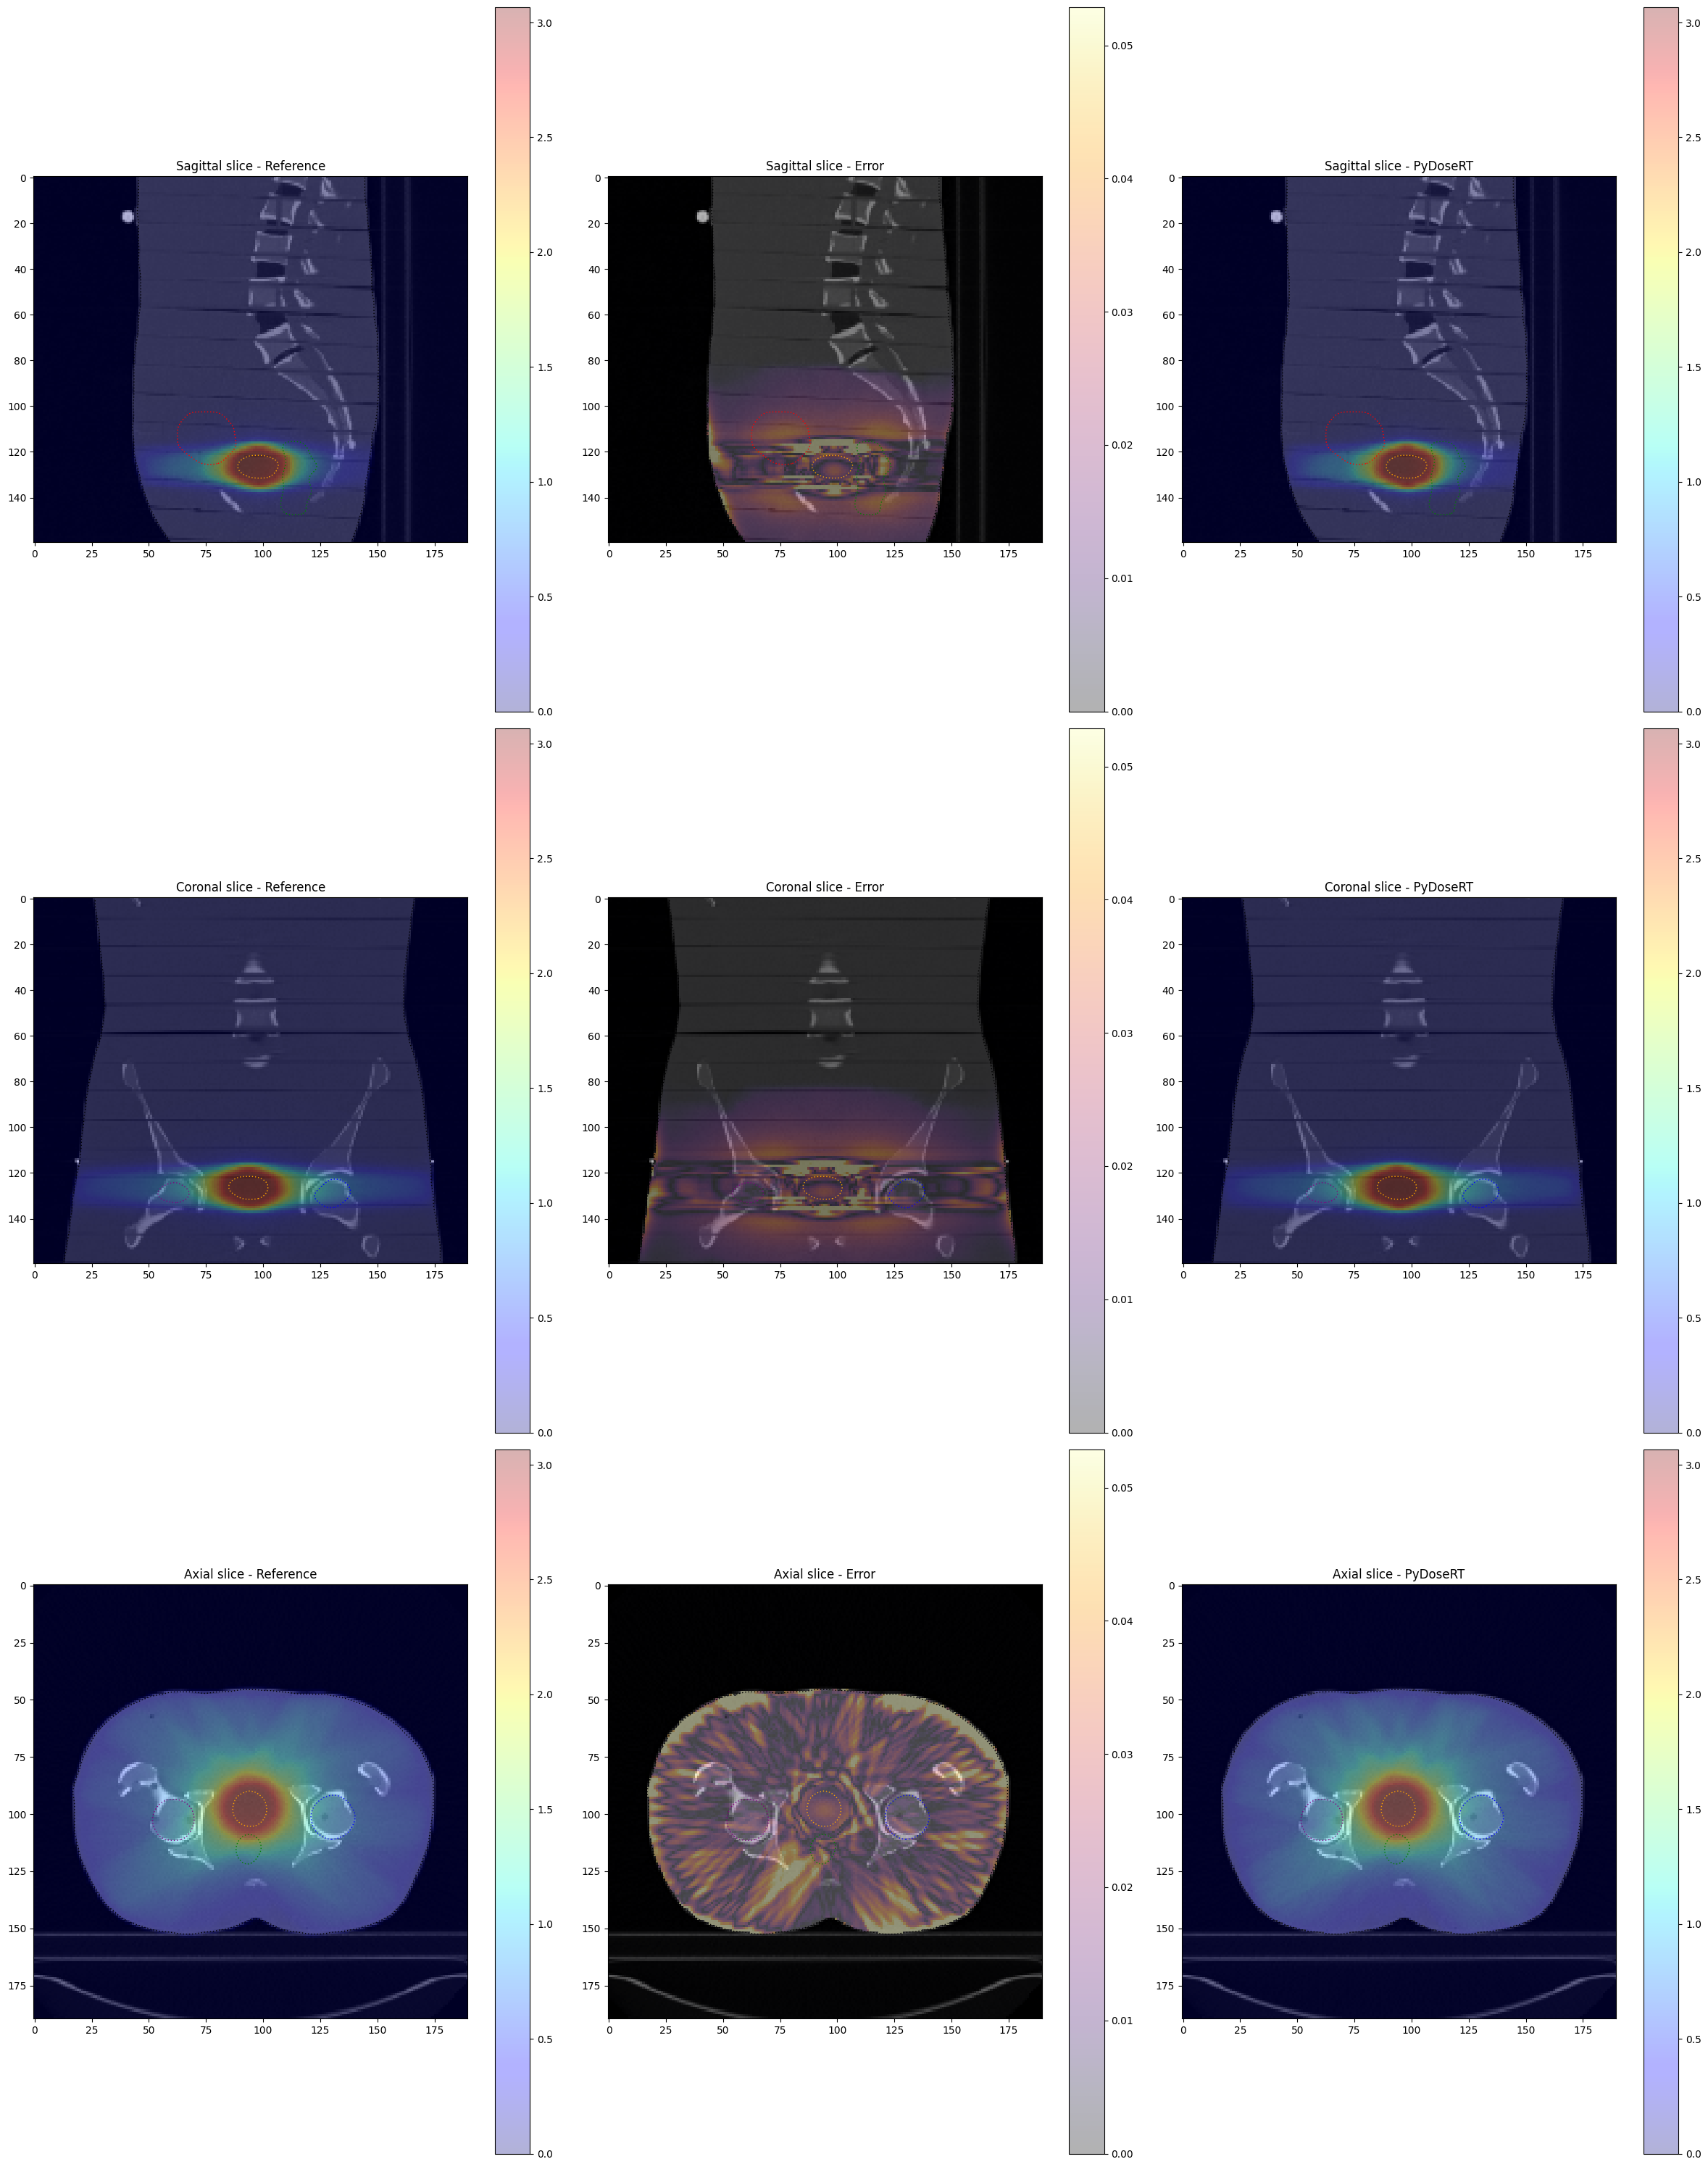

In [6]:
ct_shape = patient._ct_tensor.shape
ext_mask = patient.structures["Body"].cpu().detach().numpy() > 0

sag_slice = ct_shape[2] // 2
ax_slice = 30
cor_slice = ct_shape[1] // 2 + 2

dose_pred = ext_mask * dose_pred
dose_pred = dose_pred * (
    np.quantile(patient.dose.cpu().detach().numpy(), 0.999) / np.quantile(dose_pred, 0.999)
)

ct_volume = patient._ct_tensor.cpu().detach().numpy()
dose_volume = patient.dose.cpu().detach().numpy()
dose_pred_volume = dose_pred[0]
error_volume = ext_mask * np.abs(dose_volume - dose_pred_volume)

pred_max = np.max(dose_volume)
dose_max = np.max(dose_volume)
error_max = np.quantile(error_volume[ext_mask], 0.99)

masks = patient.structures
alpha = 0.3

plt.figure(figsize=(24, 30))

# -------------------------
# Sagittal
# -------------------------
plt.subplot(331)
plt.title("Sagittal slice - Reference")
plt.imshow(np.flipud(ct_volume[:, :, sag_slice]), cmap="gray")
plt.imshow(np.flipud(dose_volume[:, :, sag_slice]), cmap="jet", vmax=dose_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(
        np.flipud(roi.cpu().detach().numpy()[:, :, sag_slice]),
        color=color,
    )
plt.colorbar()

plt.subplot(332)
plt.title("Sagittal slice - Error")
plt.imshow(np.flipud(ct_volume[:, :, sag_slice]), cmap="gray")
plt.imshow(
    np.flipud(error_volume[:, :, sag_slice]),
    cmap="inferno",
    vmax=error_max,
    alpha=alpha,
)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(
        np.flipud(roi.cpu().detach().numpy()[:, :, sag_slice]),
        color=color,
    )
plt.colorbar()

plt.subplot(333)
plt.title("Sagittal slice - PyDoseRT")
plt.imshow(np.flipud(ct_volume[:, :, sag_slice]), cmap="gray")
plt.imshow(np.flipud(dose_pred_volume[:, :, sag_slice]), cmap="jet", vmax=pred_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(
        np.flipud(roi.cpu().detach().numpy()[:, :, sag_slice]),
        color=color,
    )
plt.colorbar()

# -------------------------
# Coronal
# -------------------------
plt.subplot(334)
plt.title("Coronal slice - Reference")
plt.imshow(np.flipud(ct_volume[:, cor_slice, :]), cmap="gray")
plt.imshow(np.flipud(dose_volume[:, cor_slice, :]), cmap="jet", vmax=dose_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(
        np.flipud(roi.cpu().detach().numpy()[:, cor_slice, :]),
        color=color,
    )
plt.colorbar()

plt.subplot(335)
plt.title("Coronal slice - Error")
plt.imshow(np.flipud(ct_volume[:, cor_slice, :]), cmap="gray")
plt.imshow(
    np.flipud(error_volume[:, cor_slice, :]),
    cmap="inferno",
    vmax=error_max,
    alpha=alpha,
)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(
        np.flipud(roi.cpu().detach().numpy()[:, cor_slice, :]),
        color=color,
    )
plt.colorbar()

plt.subplot(336)
plt.title("Coronal slice - PyDoseRT")
plt.imshow(np.flipud(ct_volume[:, cor_slice, :]), cmap="gray")
plt.imshow(np.flipud(dose_pred_volume[:, cor_slice, :]), cmap="jet", vmax=pred_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(
        np.flipud(roi.cpu().detach().numpy()[:, cor_slice, :]),
        color=color,
    )
plt.colorbar()

# -------------------------
# Axial
# -------------------------
plt.subplot(337)
plt.title("Axial slice - Reference")
plt.imshow(ct_volume[ax_slice, :, :], cmap="gray")
plt.imshow(dose_volume[ax_slice, :, :], cmap="jet", vmax=dose_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(
        roi.cpu().detach().numpy()[ax_slice, :, :],
        color=color,
    )
plt.colorbar()

plt.subplot(338)
plt.title("Axial slice - Error")
plt.imshow(ct_volume[ax_slice, :, :], cmap="gray")
plt.imshow(
    error_volume[ax_slice, :, :],
    cmap="inferno",
    vmax=error_max,
    alpha=alpha,
)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(
        roi.cpu().detach().numpy()[ax_slice, :, :],
        color=color,
    )
plt.colorbar()

plt.subplot(339)
plt.title("Axial slice - PyDoseRT")
plt.imshow(ct_volume[ax_slice, :, :], cmap="gray")
plt.imshow(dose_pred_volume[ax_slice, :, :], cmap="jet", vmax=pred_max, alpha=alpha)
for roi_name in masks.keys():
    index = list(masks.keys()).index(roi_name)
    color = list(roi_colors.values())[index]
    roi = masks[roi_name]
    overlay_mask_outline(
        roi.cpu().detach().numpy()[ax_slice, :, :],
        color=color,
    )
plt.colorbar()

plt.tight_layout()
plt.show()

## Summary

In this example, we loaded a DICOM treatment case, recomputed dose with PyDoseRT, and compared the result with the reference dose exported from the original treatment workflow.